## Dimensionality reduction

In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r

In [2]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis/feature_selection/adata_concat_feature_selection.h5ad", chunk_size = 20000)

In [3]:
adata.X = adata.layers["scran_normalization"]

## PCA

In [4]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
adata.var["highly_variable"] = adata.var["highly_deviant"]
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")

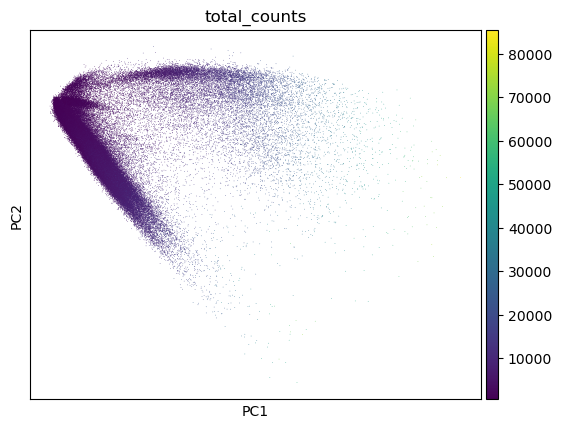

In [5]:
sc.pl.pca_scatter(adata, color="total_counts")

## UMAP

In [6]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


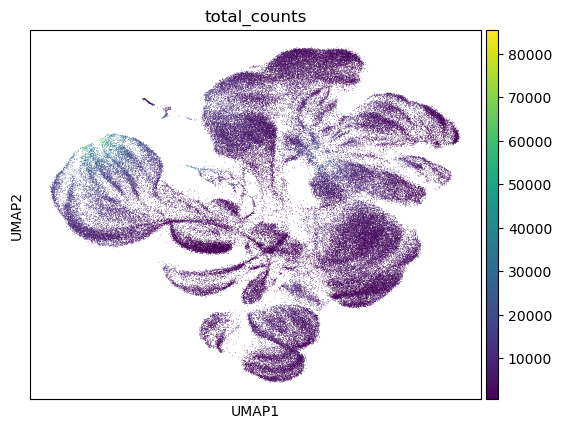

In [7]:
sc.pl.umap(adata, color="total_counts")

## Inspecting quality control metrics

In [11]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,soupx_groups,scDblFinder_score,scDblFinder_class,sample,condition,size_factors
AAACCAAAGCGCCTGA-1-S26_17,1741,7.462789,2887.0,7.968319,15.587115,21.440942,27.779702,37.062695,57.014202,28.0,...,1.386294,0.103914,False,False,0,0.000078,singlet,S26_17,Sham_LNP_circGFP,1.013672
AAACCAAAGGCGAGAC-1-S26_17,1458,7.285507,2360.0,7.766840,14.745763,20.932203,28.093220,38.474576,59.406780,32.0,...,0.693147,0.042373,False,False,0,0.000031,singlet,S26_17,Sham_LNP_circGFP,0.994896
AAACCAAAGGCTCCGA-1-S26_17,2520,7.832411,5668.0,8.642768,18.719125,25.723359,32.163020,40.508116,56.527876,48.0,...,1.098612,0.035286,False,False,3,0.022403,singlet,S26_17,Sham_LNP_circGFP,0.994861
AAACCAAAGGTGCAGA-1-S26_17,886,6.787845,1103.0,7.006695,10.063463,17.225748,26.291931,37.805984,65.004533,16.0,...,0.000000,0.000000,False,False,4,0.000282,singlet,S26_17,Sham_LNP_circGFP,0.688009
AAACCAAAGTCGCATA-1-S26_17,1109,7.012115,1730.0,7.456455,14.104046,21.502890,30.635838,42.890173,64.797688,32.0,...,0.000000,0.000000,False,False,5,0.000566,singlet,S26_17,Sham_LNP_circGFP,0.854378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTAGCCCA-1-S26_32,755,6.628041,1182.0,7.075809,14.720812,24.619289,35.109983,52.030457,78.426396,7.0,...,0.693147,0.084602,False,False,0,0.000137,singlet,S26_32,IRI_LNP_circINSR,0.811285
TGTGTTAGTAGGTCCC-1-S26_32,2209,7.700748,4861.0,8.489205,16.251800,22.197079,29.129809,38.407735,55.996708,38.0,...,2.079442,0.144003,False,False,11,0.002328,singlet,S26_32,IRI_LNP_circINSR,1.215061
TGTGTTAGTATGTCCG-1-S26_32,1395,7.241366,2239.0,7.714231,9.870478,16.971862,25.279142,37.114783,60.026798,37.0,...,1.609438,0.178651,False,False,1,0.006093,singlet,S26_32,IRI_LNP_circINSR,0.892846
TGTGTTAGTTAACCCG-1-S26_32,721,6.582025,1021.0,6.929517,14.397649,24.191969,34.769833,48.971596,78.354554,21.0,...,1.791759,0.489716,False,False,3,0.000143,singlet,S26_32,IRI_LNP_circINSR,0.668837


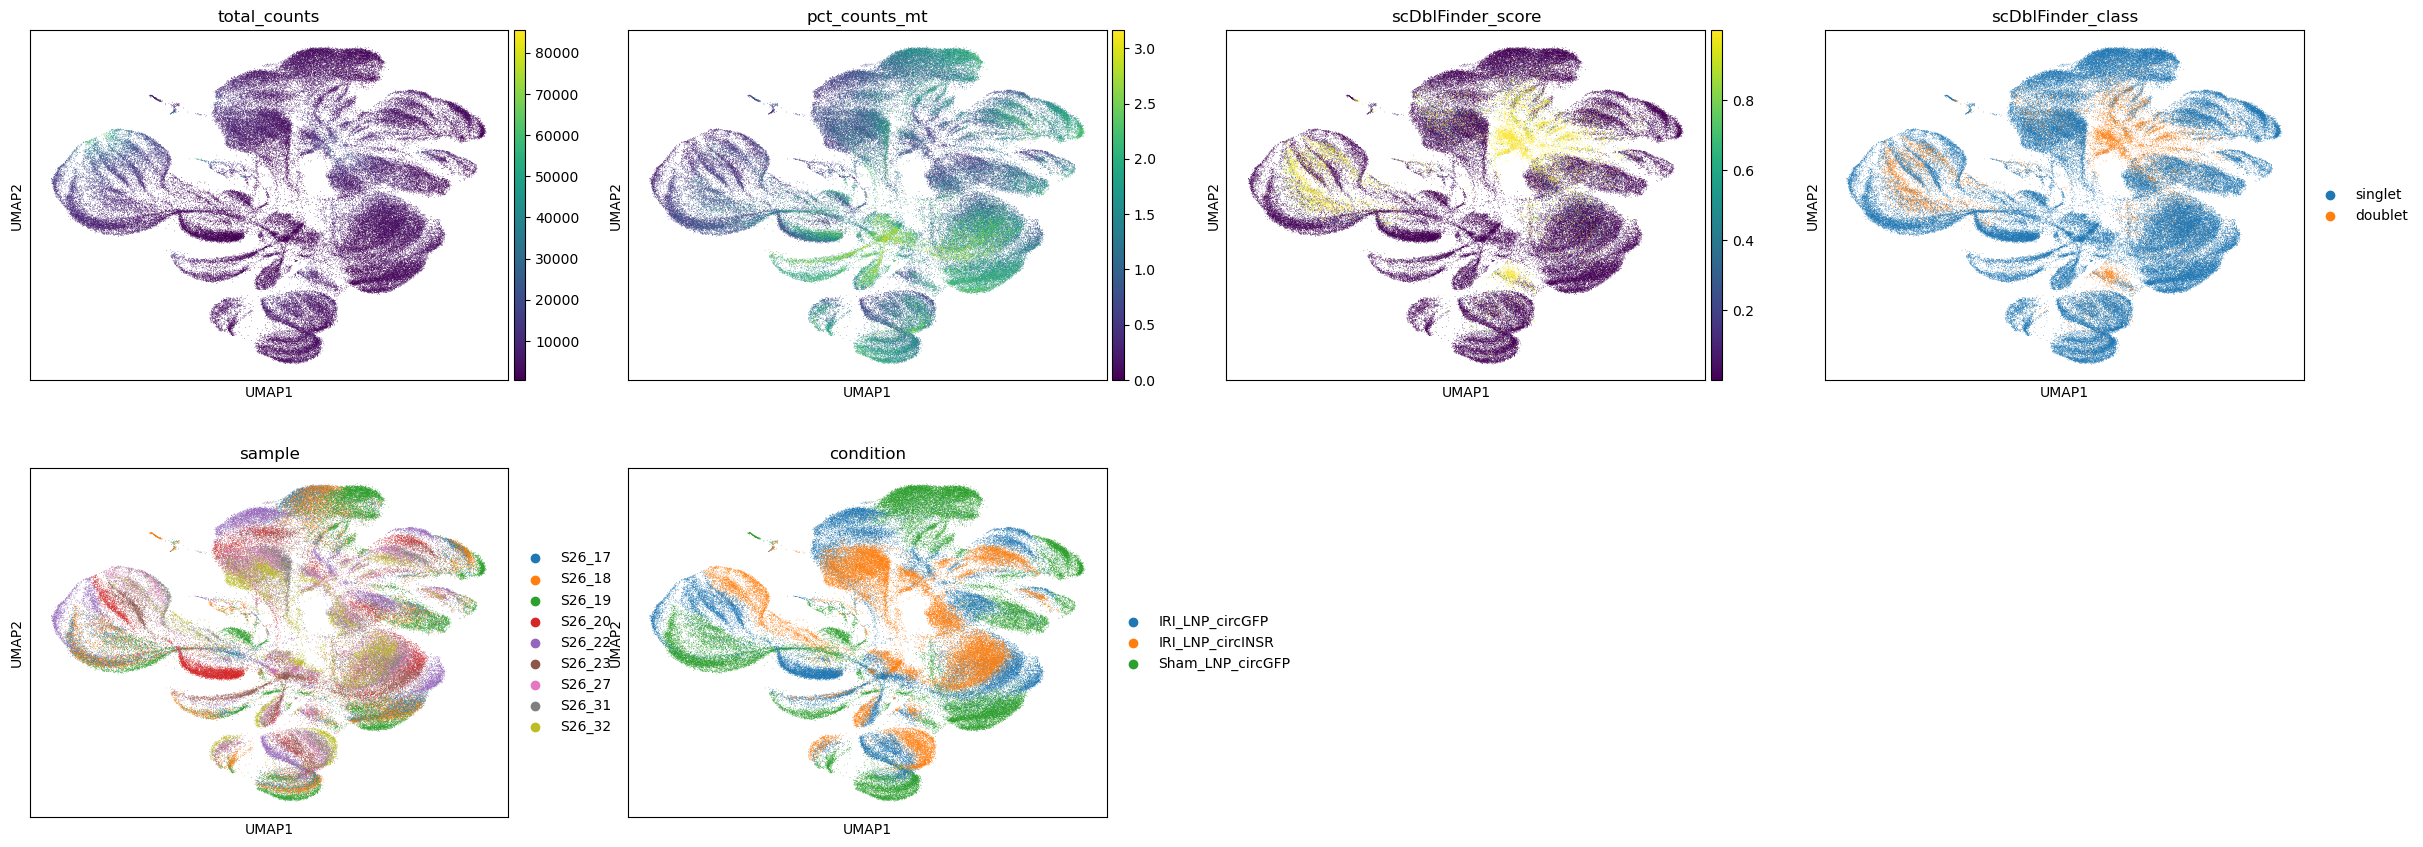

In [12]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class", "sample", "condition"],
)

In [9]:
adata.write("/projects/circ_iri/work/sc_analysis/dim_reduction/adata_concat_dim_reduction.h5ad")